## Dispersion of Fraction of Clusters ($\sigma(p)$)

Here we calculate it for the two cases in the paper: 
- Heterogeneity with parameters. 
- Heterogeneity in both parameters and topology (SWN regime).

### PART 1: Heterogeneity in parameters case (Figure 3)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import csv
from numba import njit

# Local Dynamics
@njit(parallel=False)
def fx(xold,yold,d):
    fxn=(xold**2)*(np.exp(yold-xold))+d
    return fxn
@njit(parallel=False)
def fy(xold,yold, a, q, c):
    fyn=a*(yold)-q*(xold)+c
    return fyn
#System evolution
@njit(parallel=False)
def xn(fxn, eps):
    xnew = (1-eps)*fxn + eps*np.mean(fxn)    
    return xnew


#useful parameters
N = 200
b=500
T=50000
a=0.89
q=0.18
c=0.28

#Global Evolution 
@njit(parallel=True)
def GCM_efficient(eps, N, T, b, d, a, q, c):
    initialx = np.random.uniform(1, 3, N)
    initialy = np.random.uniform(1, 4, N)

    #Matrix to save final states
    final_states = np.zeros((b, N)) 
    transient_steps = T - b

    current_x = initialx
    current_y = initialy
    
    for t in range(transient_steps):
        f_xj = fx(current_x, current_y, d)
        f_yj = fy(current_x, current_y, a, q, c)
        next_x = xn(f_xj, eps)
        next_y = f_yj
        current_x = next_x
        current_y = next_y 
    # Save final states
    for t in range(b):
        final_states[t, :] = current_x
        f_xj = fx(current_x, current_y, d)
        f_yj = fy(current_x, current_y, a, q, c)
        next_x = xn(f_xj, eps)
        next_y = f_yj
        current_x = next_x
        current_y = next_y
    return final_states
  

# Clustering Counting (minimum cluster size m)
@njit
def Clusters_m(states, delta, m):
    b, N = states.shape
    p_t = np.zeros(b)

    # safety: if m < 2, treat as original idea of at least 1 neighbor
    if m < 2:
        m = 2

    required_neighbors = m - 1

    for t in range(b):
        X = states[t]
        clustered_count = 0

        for i in range(N):
            xi = X[i]
            neigh = 0

            for j in range(N):
                if j == i:
                    continue

                if abs(xi - X[j]) < delta:
                    neigh += 1
                    # early stop: already qualifies as clustered
                    if neigh >= required_neighbors:
                        clustered_count += 1
                        break

        p_t[t] = clustered_count / N

    return p_t

    

In [4]:

# Parameters
epsilon = np.linspace(0, 1, 100)
delta = 0.0001
n_runs = 30
m = 3

# --- Dispersion measure ---
def dispersion(p_t):
    p_bar = np.mean(p_t)
    return np.sqrt(np.mean((p_t - p_bar)**2))

# --- Hard filter: D < 0.1 -> 0 ---
def filter_dispersion(D, thr=0.1):
    Df = D.copy()
    Df[Df < thr] = 0.0
    return Df

# --- Simulations ---
runs_sigma = np.zeros((len(epsilon), n_runs))

for i, eps in enumerate(epsilon):
    print(f"ε {i+1}/{len(epsilon)}  (ε = {eps:.3f})")
    for r in range(n_runs):
        noise = np.random.uniform(0.026, 0.03, N)
        d = noise
        states = GCM_efficient(eps, N, T, b, d, a, q, c)
        p_t = Clusters_m(states, delta, m)
        runs_sigma[i, r] = dispersion(p_t)

# Mean dispersion
sigma_mean = runs_sigma.mean(axis=1)

# Dispersion filter to express better the Griffiths Phase
thr = 0.1
sigma_mean_f = filter_dispersion(sigma_mean, thr)

# ---------------------------
# Exportar CSV único
# ---------------------------
data_out = np.column_stack([epsilon,runs_sigma,sigma_mean_f])

header = (["epsilon"] + [f"run_{i+1}" for i in range(n_runs)] + ["mean"])

np.savetxt("DFC-Heterogeneity-parameters.csv",data_out,delimiter=",",header=",".join(header), comments="")


ε 1/100  (ε = 0.000)
ε 2/100  (ε = 0.010)
ε 3/100  (ε = 0.020)
ε 4/100  (ε = 0.030)
ε 5/100  (ε = 0.040)
ε 6/100  (ε = 0.051)
ε 7/100  (ε = 0.061)
ε 8/100  (ε = 0.071)
ε 9/100  (ε = 0.081)
ε 10/100  (ε = 0.091)
ε 11/100  (ε = 0.101)
ε 12/100  (ε = 0.111)
ε 13/100  (ε = 0.121)
ε 14/100  (ε = 0.131)
ε 15/100  (ε = 0.141)
ε 16/100  (ε = 0.152)
ε 17/100  (ε = 0.162)
ε 18/100  (ε = 0.172)
ε 19/100  (ε = 0.182)
ε 20/100  (ε = 0.192)
ε 21/100  (ε = 0.202)
ε 22/100  (ε = 0.212)
ε 23/100  (ε = 0.222)
ε 24/100  (ε = 0.232)
ε 25/100  (ε = 0.242)
ε 26/100  (ε = 0.253)
ε 27/100  (ε = 0.263)
ε 28/100  (ε = 0.273)
ε 29/100  (ε = 0.283)
ε 30/100  (ε = 0.293)
ε 31/100  (ε = 0.303)
ε 32/100  (ε = 0.313)
ε 33/100  (ε = 0.323)
ε 34/100  (ε = 0.333)
ε 35/100  (ε = 0.343)
ε 36/100  (ε = 0.354)
ε 37/100  (ε = 0.364)
ε 38/100  (ε = 0.374)
ε 39/100  (ε = 0.384)
ε 40/100  (ε = 0.394)
ε 41/100  (ε = 0.404)
ε 42/100  (ε = 0.414)
ε 43/100  (ε = 0.424)
ε 44/100  (ε = 0.434)
ε 45/100  (ε = 0.444)
ε 46/100  (ε = 0.45

### Plot

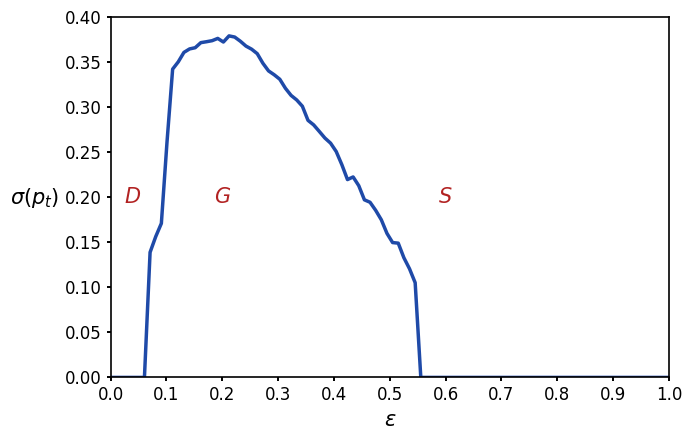

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import data
df = pd.read_csv("DFC-Heterogeneity-parameters.csv")
epsilon = df["epsilon"].values
run_cols = [c for c in df.columns if c.startswith("run_")]
runs = df[run_cols].values
sigma_mean_f = df["mean"].values 

# Plot 
plt.figure(figsize=(7, 4.5))

main = "#1f4aa8"
plt.plot(
    epsilon, sigma_mean_f,
    color=main, linewidth=2.5,
    label=rf"$<\sigma(p_t)>$"
)


ax = plt.gca()

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.2)
    ax.spines[axis].set_edgecolor('black')

ax.tick_params(axis='both', which='major', labelsize=12, width=1.4, length=3)
ax.set_xticks(np.arange(0, 1.01, 0.1))

#Labels
plt.xlabel(r"$\epsilon$", fontsize=15)
plt.ylabel(r"$\sigma(p_t)$", fontsize=15, rotation=0, labelpad=20)
ax.yaxis.set_label_coords(-0.136, 0.465)

plt.xlim(0, 1)
plt.ylim(0, 0.4)
plt.grid(False)

phase_color =  "#b22222" 

ax.text(0.04, 0.5, "D",
        transform=ax.transAxes,
        fontsize=15,
        fontstyle='italic',
        color=phase_color,
        ha='center',
        va='center')

ax.text(0.2, 0.5, "G",
        transform=ax.transAxes,
        fontsize=15,
        fontstyle='italic',
        color=phase_color,
        ha='center',
        va='center')

ax.text(0.6, 0.5, "S",
        transform=ax.transAxes,
        fontsize=15,
        fontstyle='italic',
        color=phase_color,
        ha='center',
        va='center')



plt.tight_layout()
plt.savefig("Fig3_DFC.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()


### PART 2: Heterogeneity in both parameters and topology (SWN)(Figure 6)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from numba import njit

# --- Parámetros ---
N = 200          # número de nodos
m = 40           # vecinos iniciales
p = 0.04        # probabilidad de rewiring
T = 50000
b = 500          # pasos a guardar

# Chialvo Parameters
a, q, c = 0.89, 0.18, 0.28
# Ruido uniforme específico para cada nodo
# noise = np.random.uniform(0.026, 0.03, N)
noise = np.random.uniform(0.026, 0.03, N)
# --- Red Small World ---
G = nx.watts_strogatz_graph(N, m, p)
A = nx.to_numpy_array(G, dtype=np.float64)

# --- Funciones Locales (Numba) ---
@njit
def fx(x, y, d):
    return (x**2) * np.exp(y - x) + d

@njit
def fy(x, y):
    return a*y - q*x + c

# --- Simulación del Sistema Acoplado (Numba) ---
@njit
def SWN_chialvo(T, b, A, eps, noise):
    N = A.shape[0]
    # Condiciones iniciales aleatorias
    x = np.random.uniform(1.0, 3.0, N)
    y = np.random.uniform(1.0, 4.0, N)
    
    # Buffer para guardar los últimos 'b' pasos
    x_out = np.zeros((b, N))

    for t in range(T):
        # Cálculo de dinámicas locales
        fx_all = fx(x, y, noise)
        fy_all = fy(x, y)

        x_new = np.empty(N)
        # Cálculo del acoplamiento difusivo
        for i in range(N):
            ki = A[i].sum() # Grado del nodo i
            if ki > 0:
                # Promedio del campo de los vecinos
                coupling = np.dot(A[i], fx_all) / ki
            else:
                coupling = fx_all[i]
                
            # Ecuación de estado acoplada
            x_new[i] = (1 - eps)*fx_all[i] + eps*coupling
            
        # Actualización de estados
        y = fy_all
        x = x_new

        # Guardar datos después del transiente
        if t >= T - b:
            x_out[t - (T - b)] = x

    return x_out


# Clustering Counting (minimum cluster size m)
@njit
def Clusters_m(states, delta, m):
    b, N = states.shape
    p_t = np.zeros(b)

    # safety: if m < 2, treat as original idea of at least 1 neighbor
    if m < 2:
        m = 2

    required_neighbors = m - 1

    for t in range(b):
        X = states[t]
        clustered_count = 0

        for i in range(N):
            xi = X[i]
            neigh = 0

            for j in range(N):
                if j == i:
                    continue

                if abs(xi - X[j]) < delta:
                    neigh += 1
                    # early stop: already qualifies as clustered
                    if neigh >= required_neighbors:
                        clustered_count += 1
                        break

        p_t[t] = clustered_count / N

    return p_t


In [7]:

# Parameters
epsilon = np.linspace(0, 1, 100)
delta = 0.0001
n_runs = 30
m = 3

# --- Dispersion measure ---
def dispersion(p_t):
    p_bar = np.mean(p_t)
    return np.sqrt(np.mean((p_t - p_bar)**2))

# --- Hard filter: D < 0.1 -> 0 ---
def filter_dispersion(D, thr=0.1):
    Df = D.copy()
    Df[Df < thr] = 0.0
    return Df

# --- Simulations ---
runs_sigma = np.zeros((len(epsilon), n_runs))

for i, eps in enumerate(epsilon):
    print(f"ε {i+1}/{len(epsilon)}  (ε = {eps:.3f})")
    for r in range(n_runs):
        noise = np.random.uniform(0.026, 0.03, N)
        states = SWN_chialvo(T, b, A, eps, noise)
        p_t = Clusters_m(states, delta, m)
        runs_sigma[i, r] = dispersion(p_t)

# Mean dispersion
sigma_mean = runs_sigma.mean(axis=1)

# Dispersion filter to express better the Griffiths Phase
thr = 0.1
sigma_mean_f = filter_dispersion(sigma_mean, thr)

# ---------------------------
# Exportar CSV único
# ---------------------------
data_out = np.column_stack([epsilon,runs_sigma,sigma_mean_f])

header = (["epsilon"] + [f"run_{i+1}" for i in range(n_runs)] + ["mean"])

np.savetxt("DFC-Both-Heterogeneities.csv",data_out,delimiter=",",header=",".join(header), comments="")


ε 1/100  (ε = 0.000)
ε 2/100  (ε = 0.010)
ε 3/100  (ε = 0.020)
ε 4/100  (ε = 0.030)
ε 5/100  (ε = 0.040)
ε 6/100  (ε = 0.051)
ε 7/100  (ε = 0.061)
ε 8/100  (ε = 0.071)
ε 9/100  (ε = 0.081)
ε 10/100  (ε = 0.091)
ε 11/100  (ε = 0.101)
ε 12/100  (ε = 0.111)
ε 13/100  (ε = 0.121)
ε 14/100  (ε = 0.131)
ε 15/100  (ε = 0.141)
ε 16/100  (ε = 0.152)
ε 17/100  (ε = 0.162)
ε 18/100  (ε = 0.172)
ε 19/100  (ε = 0.182)
ε 20/100  (ε = 0.192)
ε 21/100  (ε = 0.202)
ε 22/100  (ε = 0.212)
ε 23/100  (ε = 0.222)
ε 24/100  (ε = 0.232)
ε 25/100  (ε = 0.242)
ε 26/100  (ε = 0.253)
ε 27/100  (ε = 0.263)
ε 28/100  (ε = 0.273)
ε 29/100  (ε = 0.283)
ε 30/100  (ε = 0.293)
ε 31/100  (ε = 0.303)
ε 32/100  (ε = 0.313)
ε 33/100  (ε = 0.323)
ε 34/100  (ε = 0.333)
ε 35/100  (ε = 0.343)
ε 36/100  (ε = 0.354)
ε 37/100  (ε = 0.364)
ε 38/100  (ε = 0.374)
ε 39/100  (ε = 0.384)
ε 40/100  (ε = 0.394)
ε 41/100  (ε = 0.404)
ε 42/100  (ε = 0.414)
ε 43/100  (ε = 0.424)
ε 44/100  (ε = 0.434)
ε 45/100  (ε = 0.444)
ε 46/100  (ε = 0.45

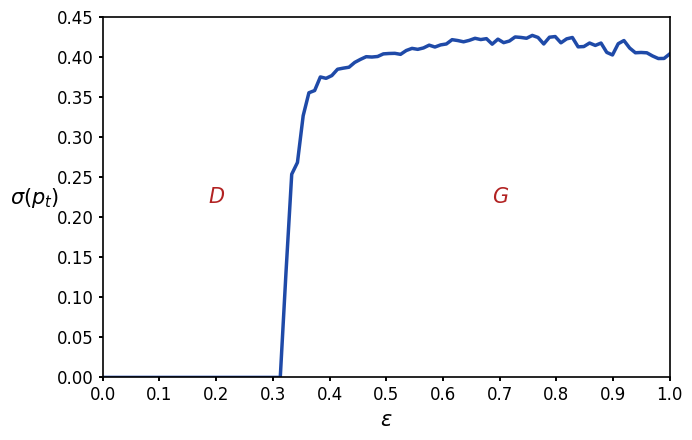

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import data
df = pd.read_csv("DFC-Both-Heterogeneities.csv")
epsilon = df["epsilon"].values
run_cols = [c for c in df.columns if c.startswith("run_")]
runs = df[run_cols].values
sigma_mean_f = df["mean"].values 

# Plot 
plt.figure(figsize=(7, 4.5))

main = "#1f4aa8"
plt.plot(
    epsilon, sigma_mean_f,
    color=main, linewidth=2.5,
    label=rf"$<\sigma(p_t)>$"
)


ax = plt.gca()

for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1.2)
    ax.spines[axis].set_edgecolor('black')

ax.tick_params(axis='both', which='major', labelsize=12, width=1.4, length=3)
ax.set_xticks(np.arange(0, 1.01, 0.1))

#Labels
plt.xlabel(r"$\epsilon$", fontsize=15)
plt.ylabel(r"$\sigma(p_t)$", fontsize=15, rotation=0, labelpad=20)
ax.yaxis.set_label_coords(-0.12, 0.465)

plt.xlim(0, 1)
plt.ylim(0, 0.45)
plt.grid(False)

phase_color =  "#b22222" 

ax.text(0.2, 0.5, "D",
        transform=ax.transAxes,
        fontsize=15,
        fontstyle='italic',
        color=phase_color,
        ha='center',
        va='center')

ax.text(0.7, 0.5, "G",
        transform=ax.transAxes,
        fontsize=15,
        fontstyle='italic',
        color=phase_color,
        ha='center',
        va='center')



plt.tight_layout()
plt.savefig("Fig6_DFC.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()
